In [ ]:
# Firedrake coupled Saarelma–Connor solver tests
#
# Run from `tests/` (so `ROOT` points at the repo). Requires Firedrake +
# parent-class deps (OpenFUSIONToolkit, eqdsk/p-file inputs).

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import os

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

INPUT_DIR = ROOT / "src" / "inputs" / "PT_Hmode"
MHD_FP = INPUT_DIR / "g150840.03000"
KPROF_FP = INPUT_DIR / "p150840.03000"

# `solver-firedrake.py` has a hyphen — load by file path.
_fd_spec = importlib.util.spec_from_file_location(
    "solver_firedrake",
    ROOT / "src" / "solver-firedrake.py",
)
_fd_mod = importlib.util.module_from_spec(_fd_spec)
_fd_spec.loader.exec_module(_fd_mod)
saarelma_connor_firedrake = _fd_mod.saarelma_connor_firedrake


In [ ]:

# Shared solve kwargs (override per cell as needed).
SOLVE_KW = dict(
    x_res=200,
    mesh_n=400,
    fe_degree=2,
    use_picard=True,
    picard_tol=1e-4,
    max_picard=40,
    relax=0.5,
    ne_inner_bc="neumann",   # Saarelma A7 default; see dirichlet comparison below
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    verbose=True,
)


In [ ]:
model = saarelma_connor_firedrake(
    P_tot_e=5e6,
    alpha_crit=1.0,
    C_KBM=0.1,
    De_chie_etg=0.5,
    nFC_x0=1e15,          # m^-3 at separatrix
    mhd_fp=str(MHD_FP),
    kprof_fp=str(KPROF_FP),
    # nFC_threshold=0.01, nCX_threshold=0.01,  # adaptive x_inner (default)
    # psi_N_inner_boundary=0.97,               # fixed inner boundary instead
)

SINGLE-EQUILIBRIA SCAN OVER SOLVER TYPES

In [ ]:
# Scan solver configurations (model free parameters unchanged — only
# use_picard, ne_inner_bc, and initial_guess vary).
import time

model = saarelma_connor_firedrake(
    P_tot_e=5e6,
    alpha_crit=0.0075,
    C_KBM=1.78,
    De_chie_etg=7.5,
    nFC_x0=3.16e15,          # m^-3 at separatrix
    mhd_fp=str(MHD_FP),
    kprof_fp=str(KPROF_FP),
    psi_N_inner_boundary=0.8906,
    nFC_threshold=None, 
    nCX_threshold=None,
    # nFC_threshold=0.01, nCX_threshold=0.01,  # adaptive x_inner (default)
    # psi_N_inner_boundary=0.97,               # fixed inner boundary instead
)

scan_results = {}

SOLVE_KW = dict(
    x_res=200,
    mesh_n=200,
    fe_degree=2,
    picard_tol=1e-4,
    max_picard=40,
    relax=0.75,
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    verbose=False,
    reuse_setup=True, # utilizes cache setup to improve timing
)

for use_picard in [False, True]:
    for ne_inner_bc in ["neumann", "dirichlet"]:
        for initial_guess in ["linear", "tanh", "pfile"]:
            key = (use_picard, ne_inner_bc, initial_guess)
            label = (
                f"Picard={use_picard}, "
                f"BC={ne_inner_bc}, IC={initial_guess}"
            )
            print(f"\n--- {label} ---")
            try:
                t0 = time.perf_counter()
                x_sol, ne_sol, nFC_sol, nCX_sol = model.solve_firedrake(
                    **SOLVE_KW,
                    use_picard=use_picard,
                    ne_inner_bc=ne_inner_bc,
                    initial_guess=initial_guess,
                )
                elapsed = time.perf_counter() - t0
                print(f"  solve_firedrake: {elapsed:.2f} s")
                scan_results[key] = dict(
                    ok=True,
                    x=x_sol,
                    ne=ne_sol,
                    nFC=nFC_sol,
                    nCX=nCX_sol,
                )
                print(
                    f"  OK  ne(sep)={float(ne_sol[np.argmin(np.abs(x_sol))]):.3e} m^-3"
                )
            except Exception as exc:
                scan_results[key] = dict(ok=False, error=str(exc))
                print(f"  FAILED: {exc}")

n_ok = sum(1 for r in scan_results.values() if r["ok"])
print(f"\nScan complete: {n_ok}/{len(scan_results)} configurations converged.")

try:
    t0_og = time.perf_counter()
    og_model_x, og_model_ne, og_model_dne_dx = model.solve(x_res=SOLVE_KW["x_res"])
    elapsed_og = time.perf_counter() - t0_og
    print(f"  model.solve (Saarelma-Connor): {elapsed_og:.2f} s")
    # All parent profiles on the same BVP grid (returned x can differ from nFC_sol
    # if an old solver build left nFC on x_prev).
    og_model_x_ref = np.asarray(model.x_sol, dtype=float)
    og_model_x = og_model_x_ref.copy()
    og_model_ne = np.asarray(model.ne_sol, dtype=float)
    og_model_nFC = np.interp(og_model_x, og_model_x_ref, np.asarray(model.nFC_sol))
    og_model_nCX = np.interp(og_model_x, og_model_x_ref, np.asarray(model.nCX_sol))
    print(
        f"  Parent solve grid: {len(og_model_x)} points "
        f"(n_e, nFC, nCX aligned)"
    )
except Exception as exc:
    print(f"  Original Model FAILED: {exc}")

In [ ]:
# Three separate overlay plots: n_e, n_FC, n_CX (all converged scan runs)
from matplotlib.lines import Line2D

linestyles = {True: "-", False: "--"}
colors_bc = {"neumann": "tab:blue", "dirichlet": "tab:orange"}


def _plot_og_saarelma_connor(ax, x_plot, y, scale, label="Original Saarelma-Connor model", x_y=None):
    """Sparse green markers for the parent ``solve()`` profile."""
    x_plot = np.asarray(x_plot, dtype=float)
    y = np.asarray(y, dtype=float)
    if x_y is None:
        x_y = x_plot
    else:
        x_y = np.asarray(x_y, dtype=float)
    if x_plot.shape != y.shape:
        y = np.interp(x_plot, x_y, y)
    markevery = max(1, len(x_plot) // 15)
    ax.plot(
        x_plot, y / scale,
        linestyle="-", color="green", marker="x",
        markevery=markevery, ms=10, mew=1.5, lw=0.8,
        label=label,
    )


def _overlay_scan_runs(ax, field, scale, ylabel, title):
    """Plot every successful scan configuration on one axes."""
    i=0
    for (use_picard, ne_inner_bc, initial_guess), res in sorted(scan_results.items()):
        if not res["ok"]:
            continue
        lbl = f"Picard={use_picard}, {ne_inner_bc.capitalize()}, {initial_guess}"
        ax.plot(
            res["x"],
            res[field] / scale,
            color=colors_bc[ne_inner_bc],
            ls=linestyles[use_picard],
            lw=1.5,
            label=lbl,
        )
        if i==0:
            ax.set_xlim(res["x"][0], res["x"][-1])
            i+=1

    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    # ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=13)
    ax.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))


# --- n_e ---
fig_ne, ax_ne = plt.subplots(figsize=(8, 5), constrained_layout=True)
_overlay_scan_runs(
    ax_ne, "ne", 1e19,
    r"$n_e$ ($10^{19}$ m$^{-3}$)",
    "Configuration scan — electron density",
)
ax_ne.plot(
    model.x_init, model.n_e_pres / 1e19, 
    "*-", color="purple", ms=7,
    label="p-file $n_e$ (experiment)",
)
try:
    _plot_og_saarelma_connor(ax_ne, og_model_x, og_model_ne, 1e19, x_y=og_model_x_ref)
except NameError:
    pass  # og_model_* not defined if parent solve failed
ax_ne.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))
ax_ne.set_ylim(1, 5.5)
plt.savefig("ne_scan.png", dpi=300)
plt.show()


# --- n_FC ---
fig_fc, ax_fc = plt.subplots(figsize=(8, 5), constrained_layout=True)
_overlay_scan_runs(
    ax_fc, "nFC", 1e15,
    r"$\langle n_{FC} \rangle$ ($10^{15}$ m$^{-3}$)",
    "Configuration scan — Franck-Condon neutrals",
)
try:
    _plot_og_saarelma_connor(ax_fc, og_model_x, og_model_nFC, 1e15, x_y=og_model_x_ref)
    ax_fc.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))
except NameError:
    pass
plt.savefig("nfc_scan.png", dpi=300)
plt.show()

# --- n_CX ---
fig_cx, ax_cx = plt.subplots(figsize=(8, 5), constrained_layout=True)
_overlay_scan_runs(
    ax_cx, "nCX", 1e15,
    r"$\langle n_{CX} \rangle$ ($10^{15}$ m$^{-3}$)",
    "Configuration scan — charge-exchange neutrals",
)
try:
    _plot_og_saarelma_connor(ax_cx, og_model_x, og_model_nCX, 1e15, x_y=og_model_x_ref)
    ax_cx.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))
except NameError:
    pass
plt.savefig("ncx_scan.png", dpi=300)
plt.show()

# Legend key: colour = inner BC, linestyle = Picard vs full Newton
legend_elems = [
    Line2D([0], [0], color=colors_bc["neumann"], lw=2, label="Neumann BC"),
    Line2D([0], [0], color=colors_bc["dirichlet"], lw=2, label="Dirichlet BC"),
    Line2D([0], [0], color="k", ls="-", lw=2, label="Picard"),
    Line2D([0], [0], color="k", ls="--", lw=2, label="Full Newton"),
]
fig_key, ax_key = plt.subplots(figsize=(4, 2))
ax_key.legend(handles=legend_elems, loc="center", fontsize=9)
ax_key.axis("off")
ax_key.set_title("Line colour = inner BC; linestyle = Picard / Newton")

plt.show()



SINGLE-EQUILIBRIA SCAN OVER FREE PARAMETERS

In [ ]:
# Build the model once — the expensive flux-surface-averaging and equilibrium
# loading runs here only, not inside the loop.

# Scan size (each dimension has N points)
N = 5

# Scan parameters
# alpha_crits = np.linspace(0.01, 2.0, 3)
# C_KBMs = np.linspace(0.01, 0.9, 3)
# De_chie_etgs = np.linspace(0.01, 0.9, 3)
# nFC_x0s = np.linspace(5e14, 9e15, 3)
alpha_crits = np.logspace(-2, 1.5, N)
C_KBMs = np.logspace(-1, 1.5, N)
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(15.5, 18.5, N)
# Inner-boundary threshold (used to compute the OUTER limit of the
# psi_N_inner_boundary scan range; smaller -> outer limit further inward).
boundary_threshold = 1e-4
# Number of points to sample between (slope-zero inner limit) and (outer limit).
n_psi_inner_pts = N
# Safety margin for the inner limit: place the deepest valid boundary at
# psi_N where dne/dx = safety_margin * min(dne/dx) rather than exactly 0.
psi_inner_safety_margin = 0.01

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox
solve_res = 200

# Output data and files
success_fp = 'success_PTHmode.txt'
failure_fp = 'failure_PTHmode.txt'
error_messages_fp = 'error_messages_PTHmode.txt'
with open(success_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")
ne_success_fp = 'scan_success_PTHmode'
verbose = False

base_model = saarelma_connor_firedrake(
        P_tot_e     = P_tot_e,
        alpha_crit  = round(float(alpha_crits[0]), 3),
        C_KBM       = round(float(C_KBMs[0]), 3),
        De_chie_etg = round(float(De_chie_etgs[0]), 3),
        nFC_x0      = round(float(nFC_x0s[0]), 3),
        mhd_fp      = MHD_FP,
        kprof_fp    = KPROF_FP,
        verbose     = verbose,
        nFC_threshold = boundary_threshold, # used initially to compute the outer limit of the boundary range
        nCX_threshold = boundary_threshold, # used initially to compute the outer limit of the boundary range
)
print("Base model built.")

In [8]:
# Clear outputs from any previous scan (including appended failure logs).
for file in os.listdir(ne_success_fp):
    os.remove(os.path.join(ne_success_fp, file))
os.remove(success_fp)
os.remove(failure_fp)
os.remove(error_messages_fp)
with open(success_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")

# run scan: for each (alpha_crit, C_KBM, De_chie_etg, nFC_x0) we recompute
# the valid range of psi_N_inner_boundary from the slope-zero inner limit to
# the nFC/nCX-threshold outer limit, then sample n_psi_inner_pts boundaries.
n_iter = 0
i=0
for alpha_crit in alpha_crits:
        j=0
        for C_KBM in C_KBMs:
                k=0
                for De_chie_etg in De_chie_etgs:
                        l=0
                        for nFC_x0 in nFC_x0s:
                                ac = round(float(alpha_crit), 3)
                                ck = round(float(C_KBM), 3)
                                de = round(float(De_chie_etg), 3)
                                nf = round(float(nFC_x0), 3)

                                # Step 1: apply free params with adaptive thresholds active so
                                # inner_boundary_limits can compute the outer limit correctly.
                                base_model.update_free_params(
                                        alpha_crit    = ac,
                                        C_KBM         = ck,
                                        De_chie_etg   = de,
                                        nFC_x0        = nf,
                                        nFC_threshold = boundary_threshold,
                                        nCX_threshold = boundary_threshold,
                                )
                                # try:
                                #         psi_inner_lim, psi_outer_lim = base_model.inner_boundary_limits(
                                #                 outer_threshold=boundary_threshold,
                                #                 safety_margin=psi_inner_safety_margin,
                                #                 x_res=solve_res,
                                #         )
                                # except Exception as e:
                                #         # Range computation failed; log and skip this combination.
                                #         with open(error_messages_fp, 'a') as f:
                                #                 f.write(f"{ac}, {ck}, {de}, {nf}, range_failed, {e}\n")
                                #         continue

                                # if psi_inner_lim >= psi_outer_lim:
                                #         psi_scan = np.array([psi_outer_lim])
                                # else:
                                #         psi_scan = np.linspace(psi_inner_lim, psi_outer_lim, n_psi_inner_pts)
                                psi_scan = np.linspace(0.85, 0.96, N)

                                m=0
                                for psi_b in psi_scan:
                                        psi_val = round(float(psi_b), 4)
                                        try:
                                                base_model.update_free_params(
                                                        alpha_crit            = ac,
                                                        C_KBM                 = ck,
                                                        De_chie_etg           = de,
                                                        nFC_x0                = nf,
                                                        psi_N_inner_boundary  = psi_val,
                                                )
                                                x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_firedrake(x_res=solve_res)
                                                sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
                                        except Exception as e: # run fails
                                                with open(failure_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                with open(error_messages_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}, {e}\n")
                                                m+=1
                                        else: # run works
                                                with open(success_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                np.save(f'{ne_success_fp}/ne_a{ac}_C{ck}_D{de}_n{nf}_b{psi_val:.4f}', sol, allow_pickle=True)
                                                m+=1
                                        n_iter += 1
                                        # if n_iter % 10 == 0: # RAM tracker
                                        #         gc.collect()
                                        #         print(f"  [{n_iter} iters] peak RAM ~ {_ram_mb():.0f} MB")
                                l+=1
                                # print(f"Completed {l} of {len(nFC_x0s)} nFC_x0s  [psi_N range: {psi_scan[0]:.3f}..{psi_scan[-1]:.3f}]") # progress logging
                        k+=1
                        # print(f"Completed {k} of {len(De_chie_etgs)} De_chie_etgs") # progress logging
                j+=1
                # print(f"Completed {j} of {len(C_KBMs)} C_KBMs") # progress logging
        i+=1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits") # progress logging

/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.376e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.424e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 3.173e-02).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 2.857e-04).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 3.395e+00).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/sr

Completed 1 of 5 alpha_crits


/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.976e-04).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 2.637e-04).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.268e+00).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.125e+00).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.284e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/sr

Completed 2 of 5 alpha_crits


/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 5.105e-04).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 2.970e+00).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 5.991e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.058e+00).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 7.825e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/sr

...

/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.207e-03).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.189e-04).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 9.330e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.001e+00).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 4.036e+00).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/sr

Completed 4 of 5 alpha_crits


/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.647e-04).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 5.262e-04).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 4.020e-02).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 1.478e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 3.328e-01).
  warnings.warn(
/Users/nelsonlab/codes/saarelma-conner-ped/sr

Completed 5 of 5 alpha_crits


/Users/nelsonlab/codes/saarelma-conner-ped/src/solver-firedrake.py:819: RuntimeWarning: Picard iteration did not reach tol=0.0001 after 40 iterations (last rel = 2.226e-01).
  warnings.warn(


Experimental p-file peak n_e: 8.237e+19 m^-3
Unique 5D scan points: 3125 (expect up to 3125 = 3125); 1875 succeeded


/var/folders/r6/8r1cpqbn0wq7td3h8x19h3kh0000gq/T/ipykernel_20883/1253884422.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


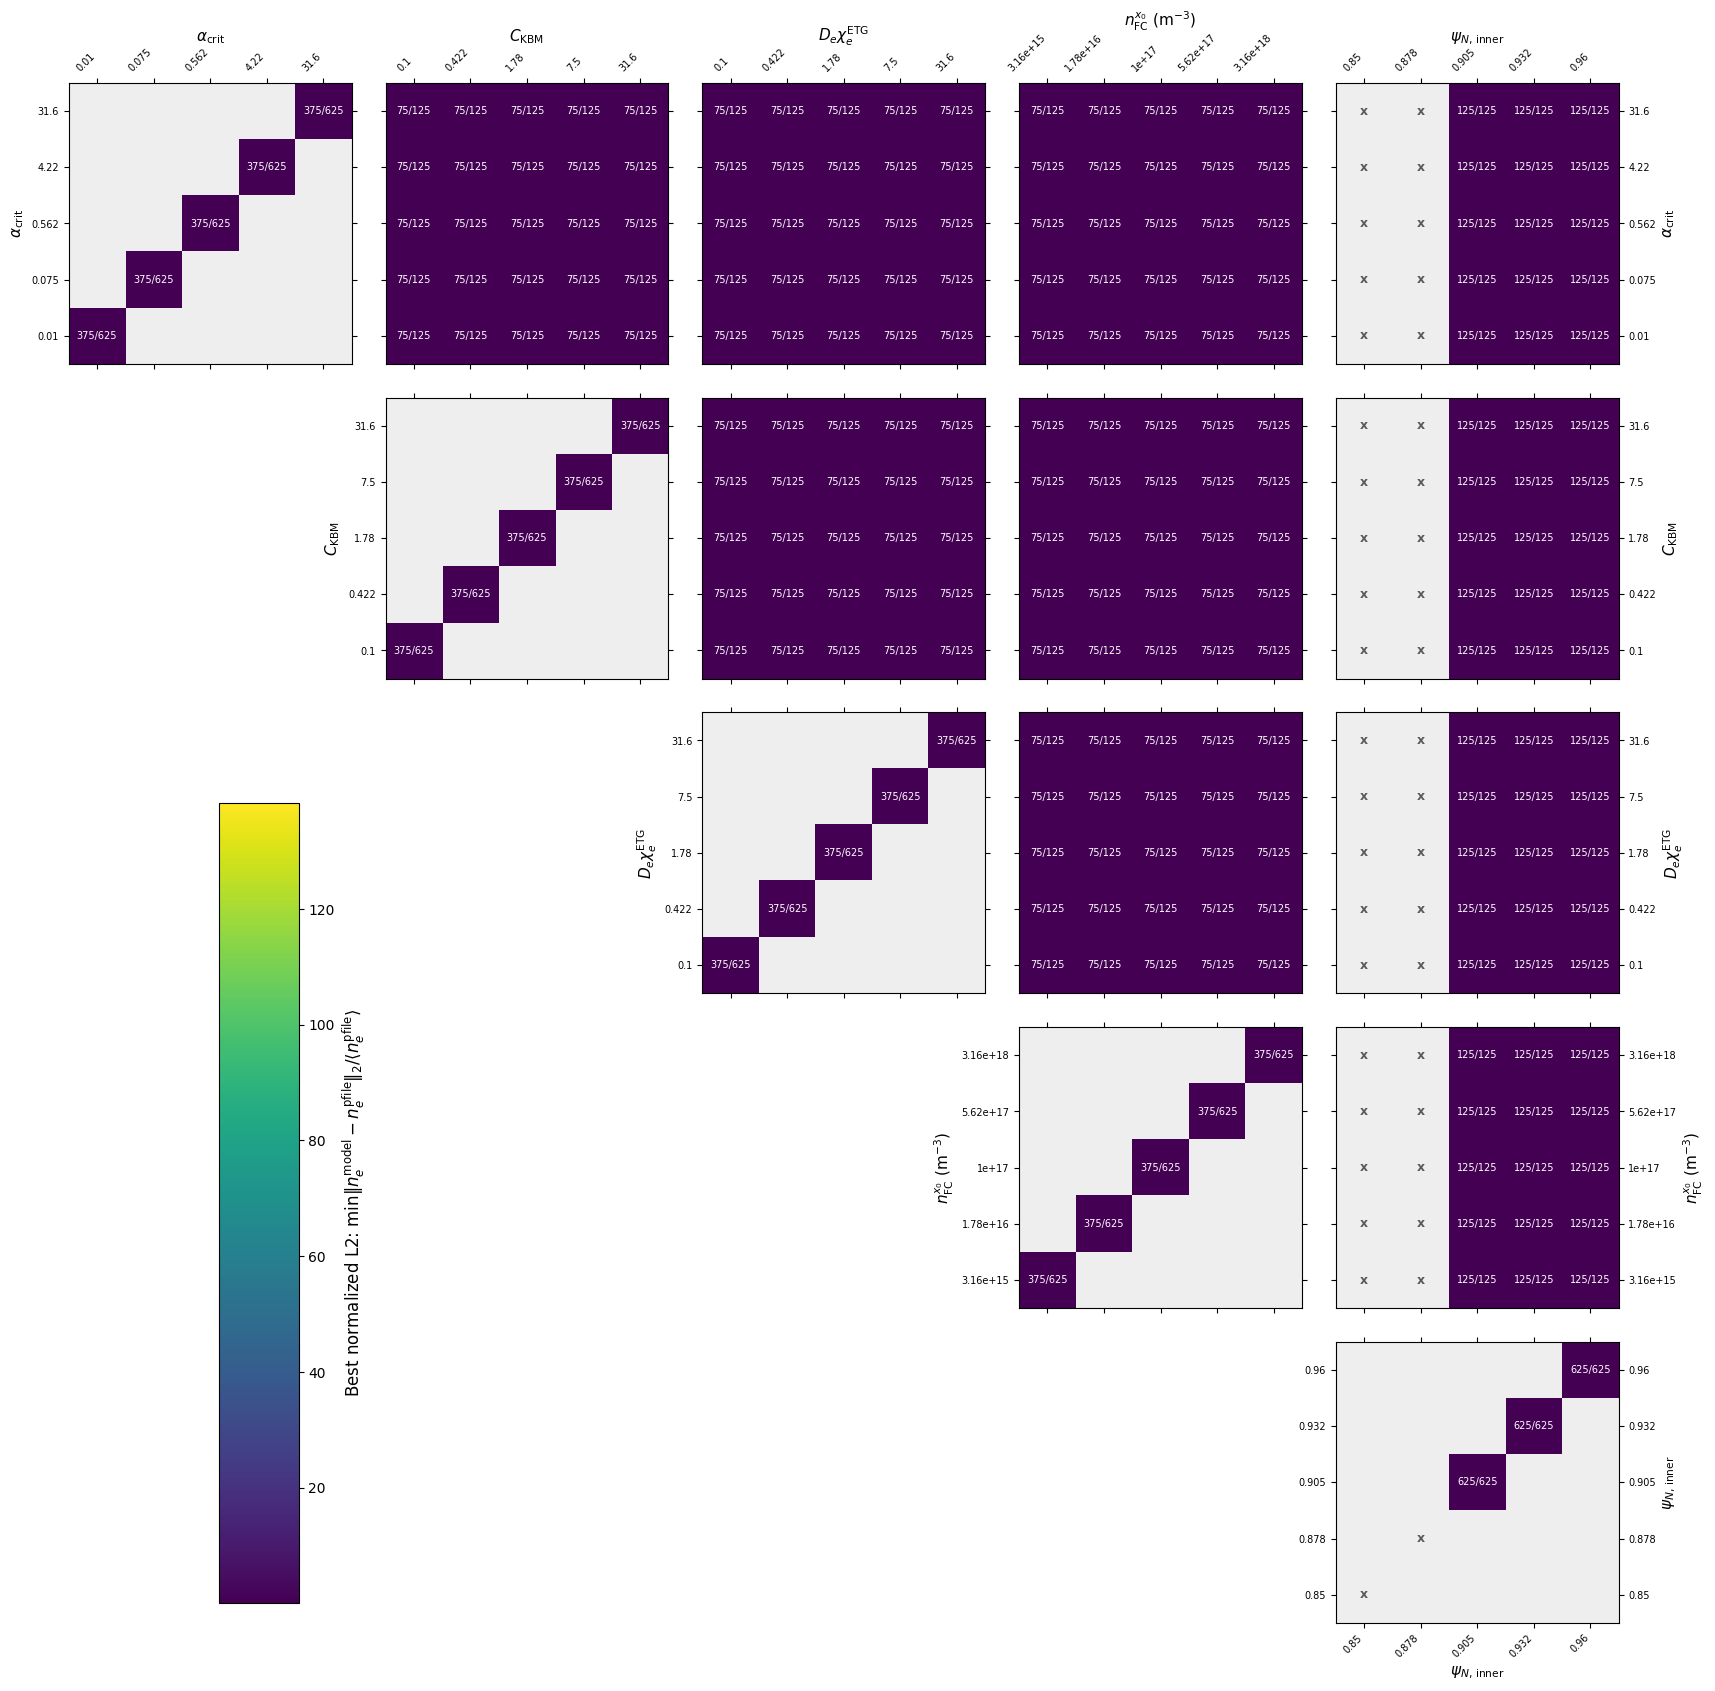

In [9]:
from matplotlib.colors import Normalize
import csv
import re
from pathlib import Path
from scipy.interpolate import interp1d

scan_dir = Path(ne_success_fp)
pattern = re.compile(r"_([a-zA-Z])([\d.eE+-]+)")

# 1. Peak density from the experimental p-file (m^-3)
def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                in_ne_block = 'ne(10^20/m^3)' in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20  # m^-3

psi_pfile, ne_pfile = read_pfile_ne(KPROF_FP)
peak_pfile = ne_pfile.max()
print(f"Experimental p-file peak n_e: {peak_pfile:.3e} m^-3")

# Build psi_N -> x mapping once (reused in cell 8)
ref = saarelma_connor_firedrake(
    P_tot_e=P_tot_e,
    alpha_crit=alpha_crits[0],
    C_KBM=C_KBMs[0],
    De_chie_etg=De_chie_etgs[0],
    nFC_x0=nFC_x0s[0],
    mhd_fp=MHD_FP,
    kprof_fp=KPROF_FP,
    verbose=False,
)
psi_to_x = interp1d(ref.psi_N_pres, ref.r_psi - ref.r_psi[-1],
                    kind='linear', bounds_error=False, fill_value='extrapolate')
# Inverse map for the secondary axis (x in meters -> psi_N).
x_to_psi = interp1d(ref.r_psi - ref.r_psi[-1], ref.psi_N_pres,
                    kind='linear', bounds_error=False, fill_value='extrapolate')

# Experimental ne mapped to x
x_pfile = psi_to_x(psi_pfile)


# Recompute normalized L2 for successful runs so this cell only depends on the
# earlier p-file mapping variables from cell 7 (psi_to_x, psi_pfile, ne_pfile,
# scan_dir, pattern).
psi_ped_grid = np.linspace(0.85, 1.0, 200)
x_ped_grid = psi_to_x(psi_ped_grid)
ne_pfile_on_ped = interp1d(psi_pfile, ne_pfile, kind='linear',
                           bounds_error=False, fill_value='extrapolate')(psi_ped_grid)
mean_ne_pfile = float(np.mean(ne_pfile_on_ped))

success_records = []  # alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_inner, normalized_l2
for npy_path in scan_dir.glob("ne_*.npy"):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    ne_pred_on_ped = interp1d(sol['x'], sol['y'], kind='linear',
                              bounds_error=False, fill_value='extrapolate')(x_ped_grid)
    l2 = np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2))
    success_records.append([
        params.get('a'), params.get('C'), params.get('D'),
        params.get('n'), params.get('b'), l2 / mean_ne_pfile,
    ])
success_arr_summary = np.array(success_records)

failure_records = []
with open(failure_fp, newline="") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        failure_records.append([float(x.strip()) for x in row])
failure_arr_summary = np.array(failure_records) if failure_records else np.empty((0, 5))

panel_names = ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0', 'psi_inner']
panel_labels = [r'$\alpha_{\mathrm{crit}}$',
                r'$C_{\mathrm{KBM}}$',
                r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
                r'$n_{\mathrm{FC}}^{x_0}$ (m$^{-3}$)',
                r'$\psi_{N,\,\mathrm{inner}}$']

all_params = success_arr_summary[:, :5]
if failure_arr_summary.size:
    all_params = np.vstack([all_params, failure_arr_summary])

# Fixed scan grids (match the scan loop: logspace for free params, linspace for psi_N).
param_values = [
    np.round(alpha_crits.astype(float), 3),
    np.round(C_KBMs.astype(float), 3),
    np.round(De_chie_etgs.astype(float), 3),
    np.round(nFC_x0s.astype(float), 3),
    np.round(np.linspace(0.85, 0.96, N), 3),
]

def _record_to_bins(record5):
    """Map one run to 5 scan-bin indices, or None if any parameter is off-grid."""
    bins = []
    for d in range(5):
        grid = param_values[d]
        val = float(record5[d])
        i = int(np.argmin(np.abs(grid - val)))
        if d == 4:
            on_grid = np.isclose(grid[i], val, atol=5e-4)
        elif d == 3:
            on_grid = np.isclose(grid[i], val, rtol=1e-3)
        else:
            on_grid = np.isclose(grid[i], val, rtol=0, atol=1e-6)
        if not on_grid:
            return None
        bins.append(i)
    return tuple(bins)

# One entry per unique 5D parameter combination (dedupe repeated log / scan lines).
# successes overwrite failures for the same combination.
run_outcomes = {}
for record in success_arr_summary:
    bins5 = _record_to_bins(record[:5])
    if bins5 is None:
        continue
    run_outcomes[bins5] = {"success": True, "l2": float(record[5])}

for record in failure_arr_summary:
    bins5 = _record_to_bins(record[:5])
    if bins5 is None:
        continue
    run_outcomes.setdefault(bins5, {"success": False})

print(
    f"Unique 5D scan points: {len(run_outcomes)} "
    f"(expect up to {N**5} = {N**5}); "
    f"{sum(1 for o in run_outcomes.values() if o['success'])} succeeded"
)

vmin = float(success_arr_summary[:, 5].min())
vmax = float(success_arr_summary[:, 5].max())
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('#eeeeee')

fig, axes = plt.subplots(5, 5, figsize=(20, 20),
                         gridspec_kw=dict(wspace=0.12, hspace=0.12))

for row in range(5):
    for col in range(5):
        ax = axes[row, col]
        if row > col:
            ax.set_visible(False)
            continue

        x_vals = param_values[col]
        y_vals = param_values[row]
        best_l2 = np.full((len(y_vals), len(x_vals)), np.nan)
        n_success = np.zeros((len(y_vals), len(x_vals)), dtype=int)
        n_total = np.zeros((len(y_vals), len(x_vals)), dtype=int)

        n_free = 5 - (1 if row == col else 2)  # diagonal panel: 4 free dims -> 5^4
        expected_per_cell = N ** n_free

        for bins5, outcome in run_outcomes.items():
            yi, xi = bins5[row], bins5[col]
            if row == col and yi != xi:
                continue
            n_total[yi, xi] += 1
            if outcome["success"]:
                n_success[yi, xi] += 1
                l2 = outcome["l2"]
                best_l2[yi, xi] = l2 if np.isnan(best_l2[yi, xi]) else min(best_l2[yi, xi], l2)

        im = ax.imshow(np.ma.masked_invalid(best_l2), origin='lower',
                       aspect='auto', cmap=cmap, norm=norm)

        # Annotate each attempted 2D bin. White text is used on darker cells;
        # black text remains readable on light/empty cells.
        for yi in range(len(y_vals)):
            for xi in range(len(x_vals)):
                if n_total[yi, xi] == 0:
                    continue
                if n_success[yi, xi] == 0:
                    ax.text(xi, yi, 'x', ha='center', va='center',
                            color='0.35', fontsize=9, fontweight='bold')
                    continue
                color = 'white' if norm(best_l2[yi, xi]) < 0.55 else 'black'
                ax.text(xi, yi, f"{n_success[yi, xi]}/{n_total[yi, xi]}",
                        ha='center', va='center', color=color, fontsize=7)

        ax.set_xticks(range(len(x_vals)))
        ax.set_yticks(range(len(y_vals)))
        ax.set_xticklabels([f"{v:.3g}" for v in x_vals], rotation=45, ha='right')
        ax.set_yticklabels([f"{v:.3g}" for v in y_vals])

        # Upper triangle (row <= col): label the outer perimeter only.
        show_top_x = row == 0
        show_bottom_x = row == 4
        show_left_y = col == row
        show_right_y = col == 4

        ax.tick_params(axis='x', which='both', bottom=True, labelbottom=show_bottom_x,
                       top=True, labeltop=show_top_x, labelsize=7)
        ax.tick_params(axis='y', which='both', left=True, labelleft=show_left_y,
                       right=True, labelright=show_right_y, labelsize=7)

        if show_bottom_x:
            ax.set_xlabel(panel_labels[col], fontsize=11)
        if show_top_x:
            ax.xaxis.set_label_position('top')
            ax.set_xlabel(panel_labels[col], fontsize=11)
        if show_left_y:
            ax.set_ylabel(panel_labels[row], fontsize=11)
        if show_right_y:
            ax.yaxis.set_label_position('right')
            ax.set_ylabel(panel_labels[row], fontsize=11)

visible_axes = [axes[r, c] for r in range(5) for c in range(5) if r <= c]
# Lower-left of the figure (in the empty lower-triangle margin).
cbar_ax = fig.add_axes([0.2, 0.12, 0.04, 0.40])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'Best normalized L2: $\min \|n_e^{\mathrm{model}} - n_e^{\mathrm{pfile}}\|_2 / \langle n_e^{\mathrm{pfile}}\rangle$',
               fontsize=12)

# fig.suptitle(
#     f"Aggregated 2D projections of 5D scan for equilibrium {Path(mhd_fp).name}\n"
#     "cell text = converged / attempted for all combinations of the other three parameters",
#     fontsize=14, y=0.92,
# )
plt.tight_layout()
plt.show()

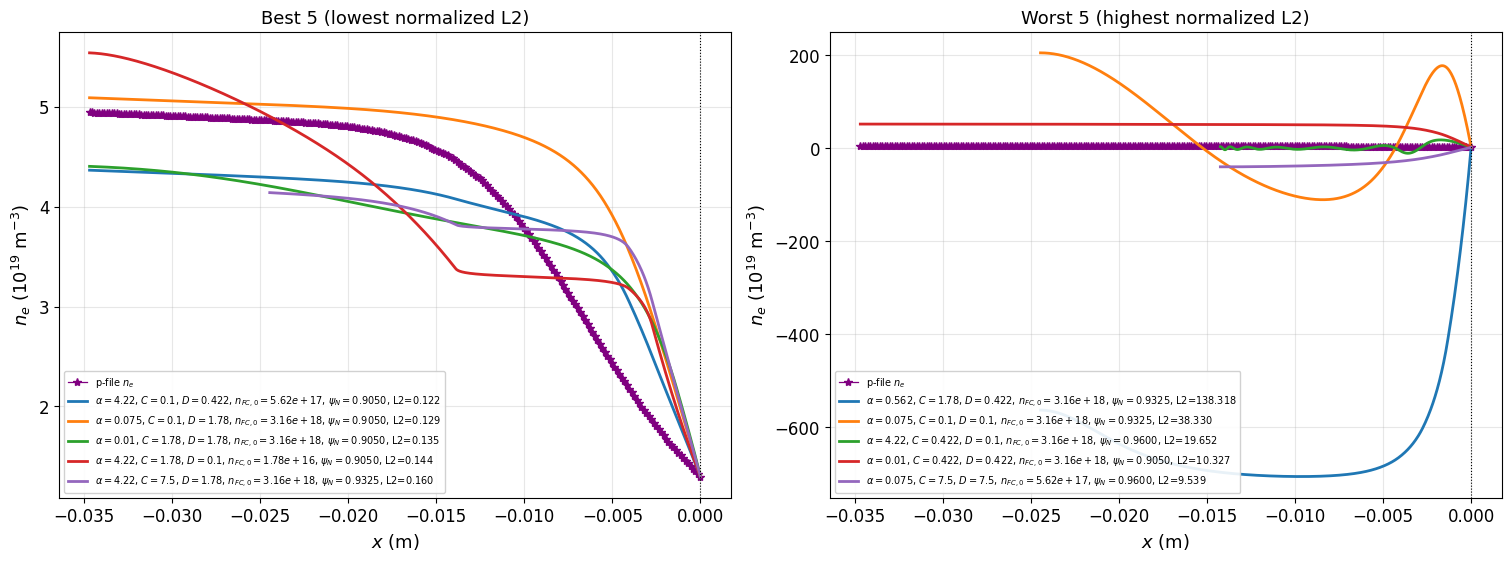

In [11]:
# Plot best 5 and worst 5 n_e profiles depending on L2 distance from p-file
profile_runs = []
for npy_path in sorted(scan_dir.glob("ne_*.npy")):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    record5 = [params.get("a"), params.get("C"), params.get("D"),
               params.get("n"), params.get("b")]
    bins5 = _record_to_bins(record5)
    if bins5 is None:
        continue

    sol = np.load(npy_path, allow_pickle=True).item()
    x_sol = np.asarray(sol['x'], dtype=float)
    ne_sol = np.asarray(sol['y'], dtype=float)
    ne_pred_on_ped = interp1d(
        x_sol, ne_sol, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_ped_grid)
    l2_norm = float(np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2)) / mean_ne_pfile)

    label = (
        rf"$\alpha={params['a']:.3g}$, $C={params['C']:.3g}$, $D={params['D']:.3g}$, "
        rf"$n_{{FC,0}}={params['n']:.2e}$, $\psi_N={params['b']:.4f}$, "
        rf"L2={l2_norm:.3f}"
    )
    entry = dict(l2=l2_norm, label=label, x=x_sol, ne=ne_sol, bins5=bins5)
    prev = next((r for r in profile_runs if r["bins5"] == bins5), None)
    if prev is None or l2_norm < prev["l2"]:
        if prev is not None:
            profile_runs.remove(prev)
        profile_runs.append(entry)

profile_runs.sort(key=lambda r: r["l2"])
n_show = min(5, len(profile_runs))
if n_show == 0:
    print("No on-grid successful scan profiles found — run the scan cell first.")
else:
    best = profile_runs[:n_show]
    worst = profile_runs[-n_show:][::-1]

    fig, (ax_best, ax_worst) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    for ax, subset, title in (
        (ax_best, best, f"Best {n_show} (lowest normalized L2)"),
        (ax_worst, worst, f"Worst {n_show} (highest normalized L2)"),
    ):
        x_lo = min(r["x"].min() for r in subset)
        x_hi = max(r["x"].max() for r in subset)
        x_plot = np.linspace(x_lo, x_hi, 250)
        psi_on_plot = x_to_psi(x_plot)
        ne_pfile_on_x = interp1d(
            psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
        )(psi_on_plot)
        ax.plot(
            x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=0.9,
            label="p-file $n_e$",
        )

        for i, run in enumerate(subset):
            ax.plot(
                run["x"], run["ne"] / 1e19,
                color=plt.cm.tab10(i), lw=2.0, label=run["label"],
            )
        ax.axvline(0, color="k", ls=":", lw=0.8)
        ax.set_xlabel(r"$x$ (m)", fontsize=13)
        ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
        ax.set_title(title, fontsize=13)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=12)
        ax.legend(fontsize=7, loc="lower left", framealpha=0.9)

    plt.savefig("ne_best_worst_L2.png", dpi=300)
    plt.show()

